# UK CPI Time Series Analysis

This notebook applies autoregressive modelling to the UK Consumer Price Index using ONS data, and explores whether gilt-implied inflation expectations from the Bank of England improve forecast accuracy when used as an exogenous regressor.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

We begin by reading the ONS CPI All Items index (series D7BT, 2015=100) into a dataframe. The CSV downloaded from the ONS time series page contains metadata rows, annual aggregates, quarterly aggregates, and monthly observations -- we extract only the monthly data.

In [2]:
# Read the ONS time series CSV (series D7BT from dataset MM23)
# We use a regex to isolate the monthly rows (format 'YYYY MMM')
ons_file = 'series-050326.csv'  
raw = pd.read_csv(ons_file, header=None, names=['period', 'value'])

month_pattern = re.compile(r'^\d{4} [A-Z]{3}$')
monthly_mask = raw['period'].apply(lambda x: bool(month_pattern.match(str(x).strip())))
uk_cpi = raw[monthly_mask].copy()
uk_cpi['value'] = pd.to_numeric(uk_cpi['value'], errors='coerce')
uk_cpi['date'] = pd.to_datetime(uk_cpi['period'], format='%Y %b')
uk_cpi = uk_cpi.dropna(subset=['value']).reset_index(drop=True)
uk_cpi.rename(columns={'value': 'CPI'}, inplace=True)

print(f'Loaded {len(uk_cpi)} monthly CPI observations')
print(f'Date range: {uk_cpi.date.min().strftime("%b %Y")} to {uk_cpi.date.max().strftime("%b %Y")}')
uk_cpi[['date', 'CPI']].tail(10)

Loaded 457 monthly CPI observations
Date range: Jan 1988 to Jan 2026


,date,CPI
447,2025-04-01,138.2
448,2025-05-01,138.4
449,2025-06-01,138.9
450,2025-07-01,139.0
451,2025-08-01,139.3
452,2025-09-01,139.3
453,2025-10-01,139.8
454,2025-11-01,139.5
455,2025-12-01,140.1
456,2026-01-01,139.5


We restrict the sample to January 2010 onwards, avoiding the structural break around the 2008-09 financial crisis, and split into training and test sets. The last 24 months are held out for out-of-sample evaluation.

In [3]:
# Filter to 2010 onwards and create integer time index
uk_cpi = uk_cpi[uk_cpi['date'] >= '2010-01-01'].reset_index(drop=True)
uk_cpi['t'] = range(len(uk_cpi))

# Hold out last 24 months as test set
split_point = len(uk_cpi) - 24
cpi_train = uk_cpi.iloc[:split_point].copy()
cpi_test = uk_cpi.iloc[split_point:].copy()

print(f'Training: {cpi_train.date.min().strftime("%b %Y")} to {cpi_train.date.max().strftime("%b %Y")} ({len(cpi_train)} obs)')
print(f'Test:     {cpi_test.date.min().strftime("%b %Y")} to {cpi_test.date.max().strftime("%b %Y")} ({len(cpi_test)} obs)')

Training: Jan 2010 to Jan 2024 (169 obs)
Test:     Feb 2024 to Jan 2026 (24 obs)


We start by visualising the CPI series with the train/test boundary marked.

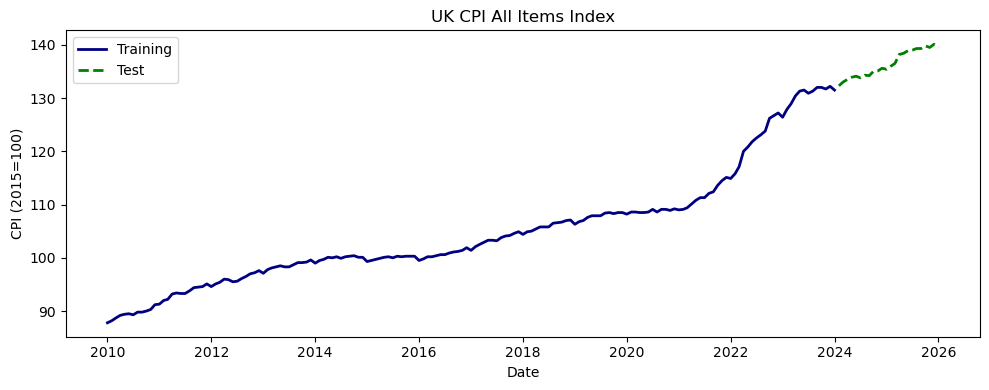

In [4]:
fig, ax = plt.subplots()
ax.plot(cpi_train['date'], cpi_train['CPI'], color='navy', linewidth=2, label='Training')
ax.plot(cpi_test['date'], cpi_test['CPI'], color='green', linewidth=2, linestyle='--', label='Test')
ax.set_xlabel('Date')
ax.set_ylabel('CPI (2015=100)')
ax.set_title('UK CPI All Items Index')
ax.legend()
plt.tight_layout()
plt.show()

The series has a clear upward deterministic trend. We fit a linear model to capture this and subtract it from the data, leaving a residual that should be closer to stationary.

## Detrending

We fit the linear trend on the training data only and extrapolate it onto the test period -- this avoids leaking future information into the detrending step.

> $\textit{Note:}$ An alternative would be to take the first difference of $\log(CPI)$, which is the standard approach in economics. We use linear detrending here because it makes the "add trend back" step straightforward, but both methods are implemented for comparison later.

In [5]:
# Fit a linear trend on training data only
trend_model = LinearRegression()
trend_model.fit(cpi_train[['t']], cpi_train['CPI'])

slope = trend_model.coef_[0]
intercept = trend_model.intercept_
print(f'Fitted linear trend: CPI(t) = {slope:.4f} * t + {intercept:.4f}')

# Compute and subtract trend for both partitions
cpi_train['trend'] = trend_model.predict(cpi_train[['t']])
cpi_test['trend'] = trend_model.predict(cpi_test[['t']])

cpi_train['detrended'] = cpi_train['CPI'] - cpi_train['trend']
cpi_test['detrended'] = cpi_test['CPI'] - cpi_test['trend']

Fitted linear trend: CPI(t) = 0.2068 * t + 87.6122


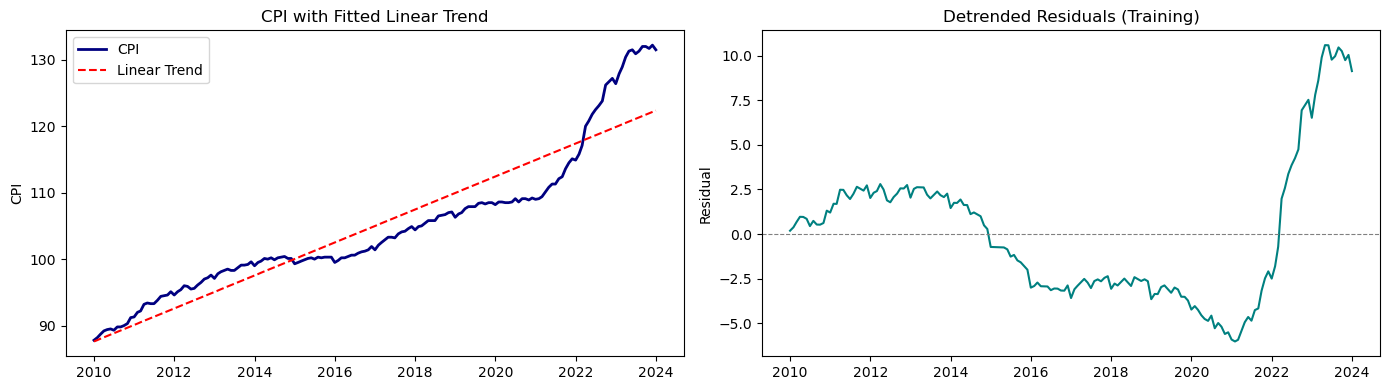

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: CPI with trend overlay
axes[0].plot(cpi_train['date'], cpi_train['CPI'], 'navy', linewidth=2, label='CPI')
axes[0].plot(cpi_train['date'], cpi_train['trend'], 'r--', linewidth=1.5, label='Linear Trend')
axes[0].set_title('CPI with Fitted Linear Trend')
axes[0].set_ylabel('CPI')
axes[0].legend()

# Right: Detrended residuals
axes[1].plot(cpi_train['date'], cpi_train['detrended'], 'teal', linewidth=1.5)
axes[1].axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
axes[1].set_title('Detrended Residuals (Training)')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

The residual fluctuates around zero with no obvious remaining trend or seasonality. We take the linear trend as sufficient and proceed directly to fitting an AR model. To choose the model order, we examine the ACF and PACF plots.

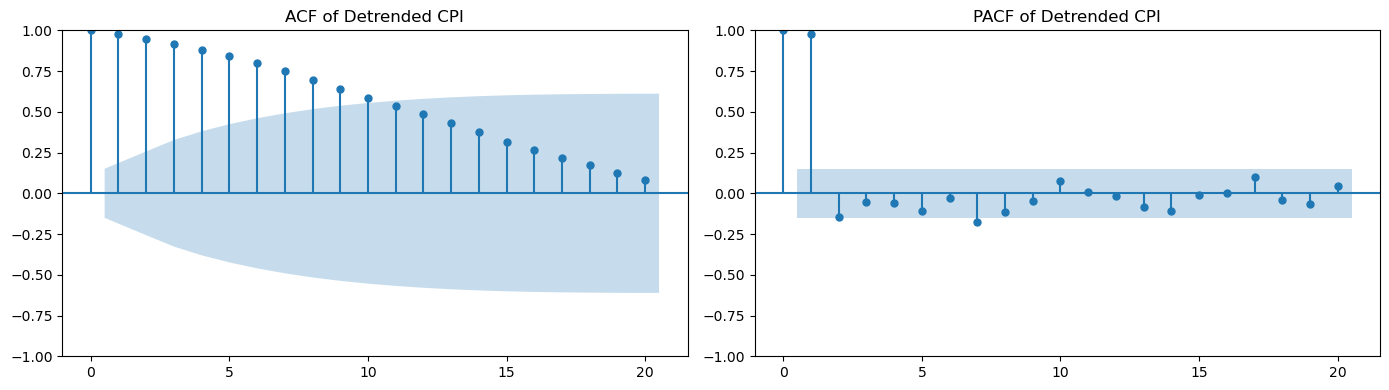

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(cpi_train['detrended'].dropna(), ax=axes[0], lags=20, title='ACF of Detrended CPI')
plot_pacf(cpi_train['detrended'].dropna(), ax=axes[1], lags=20, title='PACF of Detrended CPI')
plt.tight_layout()
plt.show()

The PACF shows significant partial autocorrelation at the first couple of lags, suggesting an AR(2) model. We verify this by computing the training RMSE across a range of lag orders.

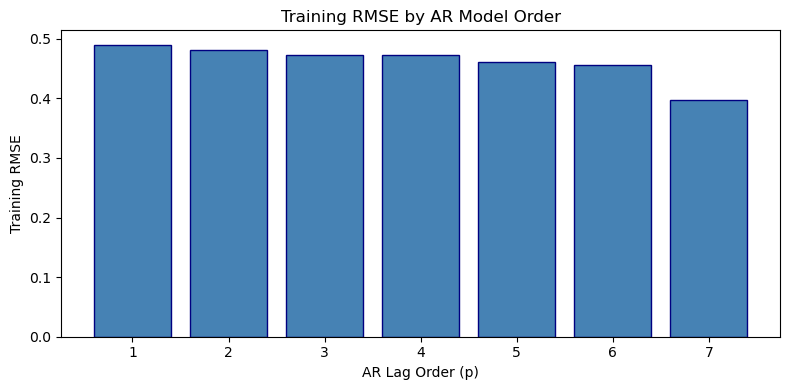

Lowest training RMSE at lag p = 7 (RMSE = 0.3964)


In [8]:
# Evaluate training RMSE for AR models of order 1 through 7
train_resid = cpi_train['detrended'].values
rmse_by_lag = []

for p in range(1, 8):
    ar_fit = AutoReg(train_resid, lags=p, trend='n').fit()
    preds = ar_fit.predict(start=p, end=len(train_resid)-1)
    rmse_val = np.sqrt(mean_squared_error(train_resid[p:], preds))
    rmse_by_lag.append(rmse_val)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 8), rmse_by_lag, color='steelblue', edgecolor='navy')
ax.set_xlabel('AR Lag Order (p)')
ax.set_ylabel('Training RMSE')
ax.set_title('Training RMSE by AR Model Order')
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

best_p = np.argmin(rmse_by_lag) + 1
print(f'Lowest training RMSE at lag p = {best_p} (RMSE = {rmse_by_lag[best_p-1]:.4f})')

Training RMSE alone can be misleading since it will always decrease with more parameters. We also compute test-set RMSE using a walk-forward scheme: at each test step we predict one step ahead using actual past values.

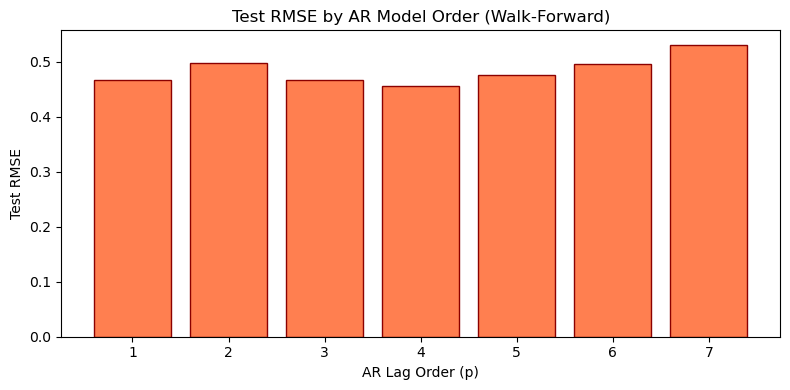

Lowest test RMSE at lag p = 4 (RMSE = 0.4569)


In [9]:
test_resid = cpi_test['detrended'].values
rmse_test_by_lag = []

for p in range(1, 8):
    ar_fit = AutoReg(train_resid, lags=p, trend='c').fit()
    coeffs = ar_fit.params
    
    # Walk-forward prediction on the test set
    history = list(train_resid[-p:])
    test_preds = []
    for j in range(len(test_resid)):
        # AR prediction: const + sum(coef_i * y_{t-i})
        yhat = coeffs[0]  # intercept
        for i in range(1, p + 1):
            yhat += coeffs[i] * history[-i]
        test_preds.append(yhat)
        history.append(test_resid[j])  # use actual value for next step
    
    rmse_val = np.sqrt(mean_squared_error(test_resid, test_preds))
    rmse_test_by_lag.append(rmse_val)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 8), rmse_test_by_lag, color='coral', edgecolor='darkred')
ax.set_xlabel('AR Lag Order (p)')
ax.set_ylabel('Test RMSE')
ax.set_title('Test RMSE by AR Model Order (Walk-Forward)')
ax.set_xticks(range(1, 8))
plt.tight_layout()
plt.show()

best_test_p = np.argmin(rmse_test_by_lag) + 1
print(f'Lowest test RMSE at lag p = {best_test_p} (RMSE = {rmse_test_by_lag[best_test_p-1]:.4f})')

There may be some discrepancy between the PACF suggestion and the RMSE minimum -- this is common with finite samples. We proceed with AR(2) to avoid discarding potentially informative lag structure, and build the model below.

In [24]:
# AR(2)
chosen_p = 2
ar_model = AutoReg(train_resid, lags=chosen_p, trend='c').fit()
print(f'AR({chosen_p}) coefficients:')
print(ar_model.params)

# Walk-forward forecast on test set
ar_coeffs = ar_model.params
history = list(train_resid[-chosen_p:])
ar_test_forecasts = []

for j in range(len(test_resid)):
    yhat = ar_coeffs[0]
    for i in range(1, chosen_p + 1):
        yhat += ar_coeffs[i] * history[-i]
    ar_test_forecasts.append(yhat)
    history.append(test_resid[j])

# Add the linear trend back to recover CPI-level forecasts
ar_cpi_forecast = np.array(ar_test_forecasts) + cpi_test['trend'].values

# In-sample fitted values for diagnostics
ar_train_fitted = ar_model.predict(start=chosen_p, end=len(train_resid)-1)
ar_cpi_train_fitted = ar_train_fitted + cpi_train['trend'].values[chosen_p:]

AR(2) coefficients:
[ 0.04135396  1.19425081 -0.19093711]


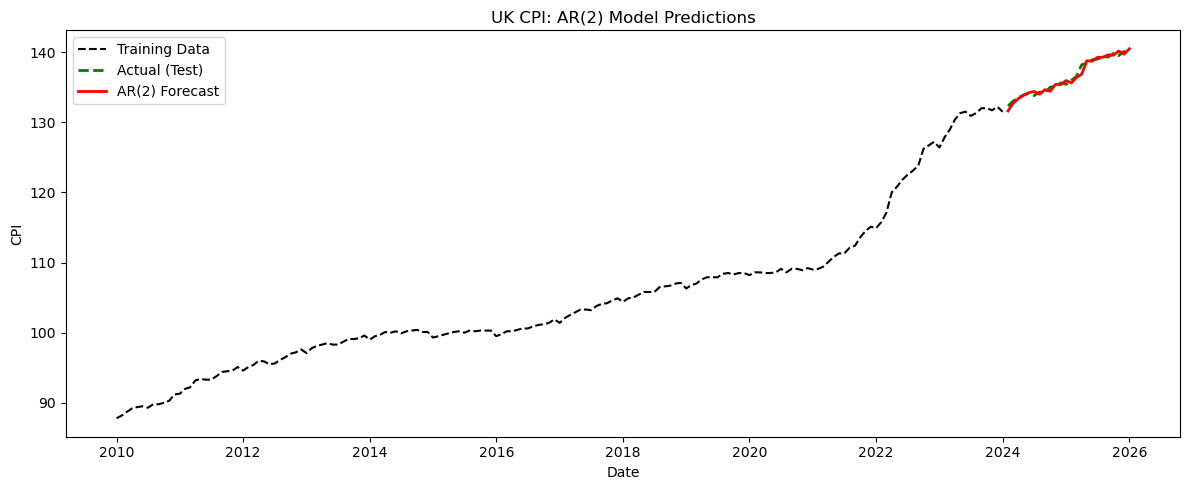

AR(2) Test RMSE on CPI level: 0.4981


In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cpi_train['date'], cpi_train['CPI'], 'k--', linewidth=1.5, label='Training Data')
ax.plot(cpi_test['date'], cpi_test['CPI'], 'g--', linewidth=2, label='Actual (Test)')
ax.plot(cpi_test['date'], ar_cpi_forecast, 'r-', linewidth=2, label=f'AR({chosen_p}) Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('CPI')
ax.set_title(f'UK CPI: AR({chosen_p}) Model Predictions')
ax.legend()
plt.tight_layout()
plt.show()

ar_rmse = np.sqrt(mean_squared_error(cpi_test['CPI'], ar_cpi_forecast))
print(f'AR({chosen_p}) Test RMSE on CPI level: {ar_rmse:.4f}')

The AR(2) predictions track the test data reasonably well. To check whether the model has captured the autocorrelation structure adequately, we plot the PACF of the training residuals -- ideally these should resemble white noise.

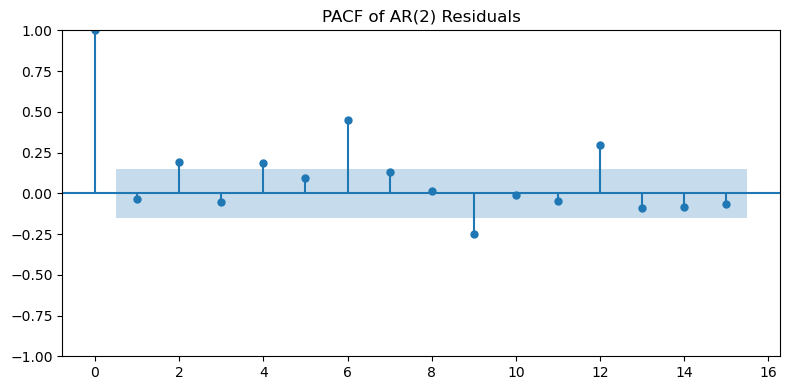

In [12]:
ar_residuals = train_resid[chosen_p:] - ar_train_fitted
fig, ax = plt.subplots(figsize=(8, 4))
plot_pacf(ar_residuals, ax=ax, lags=15, title=f'PACF of AR({chosen_p}) Residuals')
plt.tight_layout()
plt.show()

## Inflation Rates

Since we will be working with an external regressor (the BoE implied inflation rate) that is expressed as a rate, we need to convert the CPI index into monthly inflation rates to put everything on a comparable footing. The simple percentage change is:

> $IR_t = \frac{CPI_t - CPI_{t-1}}{CPI_{t-1}} \times 100$

We also compute the log-difference approximation $\Delta \log(CPI_t) \times 100$, which economists generally prefer because it is additive over time.

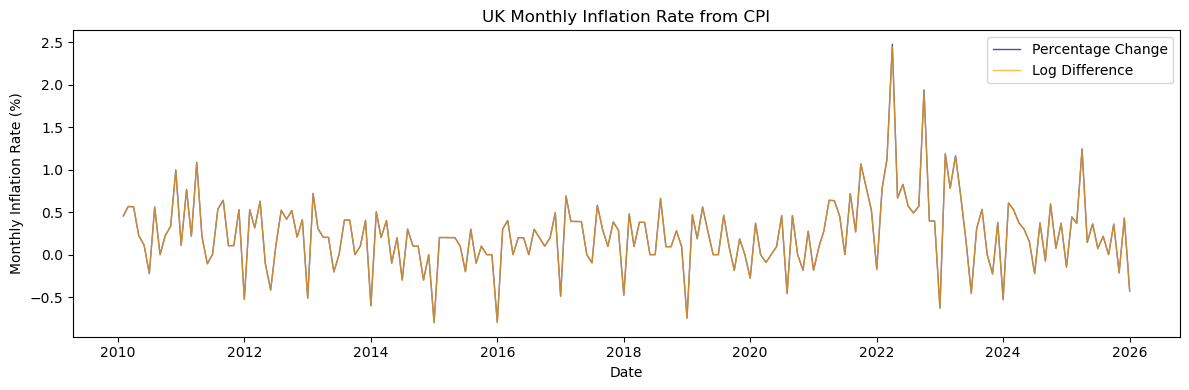

In [13]:
def compute_monthly_inflation(cpi_values):
    """Month-on-month percentage change."""
    ir = []
    for i in range(1, len(cpi_values)):
        ir_temp = (cpi_values[i] - cpi_values[i-1]) / cpi_values[i-1] * 100
        ir.append(ir_temp)
    return ir

# Both methods side by side
uk_cpi['ir_pct'] = uk_cpi['CPI'].pct_change() * 100
uk_cpi['ir_log'] = np.log(uk_cpi['CPI']).diff() * 100

cpi_ir_train = uk_cpi.iloc[:split_point].copy()
cpi_ir_test = uk_cpi.iloc[split_point:].copy()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(uk_cpi['date'], uk_cpi['ir_pct'], 'navy', linewidth=1, alpha=0.7, label='Percentage Change')
ax.plot(uk_cpi['date'], uk_cpi['ir_log'], 'orange', linewidth=1, alpha=0.7, label='Log Difference')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Inflation Rate (%)')
ax.set_title('UK Monthly Inflation Rate from CPI')
ax.legend()
plt.tight_layout()
plt.show()

## Gilt-Implied Inflation

The Bank of England publishes an implied inflation term structure derived from the spread between nominal and index-linked gilt yields. We use the 10-year inflation implied forward rate (series IUMAMIIF, monthly average) as our exogenous variable. This is reported as an annualised rate, so we deannualise it:

> $IR^{implied}_t = \left(1 + \frac{BEI_t}{100}\right)^{1/12} - 1$

In [14]:
# Load BoE implied inflation (series IUMAMIIF, 10y Inflation Implied Forward, monthly avg)
# Source: https://www.bankofengland.co.uk/boeapps/database/
boe_file = 'results.csv'
boe_raw = pd.read_csv(boe_file)
boe_raw.columns = ['date', 'implied_inflation_10y']
boe_raw['date'] = pd.to_datetime(boe_raw['date'], format='%d %b %Y')
boe_raw['implied_inflation_10y'] = pd.to_numeric(boe_raw['implied_inflation_10y'], errors='coerce')
boe_raw = boe_raw.dropna()

# Snap to first-of-month to align with CPI dates
boe_monthly = boe_raw.copy()
boe_monthly['date'] = boe_monthly['date'].dt.to_period('M').dt.to_timestamp()

boe_monthly.head()

,date,implied_inflation_10y
0,2010-01-01,4.0487
1,2010-02-01,3.9437
2,2010-03-01,4.2015
3,2010-04-01,4.3286
4,2010-05-01,4.0850


We deannualise the implied inflation and merge the two series on date. The overlay plot below gives a visual sense of how the market-implied rate compares to realised CPI inflation.

In [15]:
# Deannualise to monthly rate and merge with CPI data
boe_monthly['ir_implied'] = ((1 + boe_monthly['implied_inflation_10y']/100)**(1/12) - 1) * 100

merged = pd.merge(
    uk_cpi[['date', 't', 'ir_pct']].dropna(),
    boe_monthly[['date', 'ir_implied']],
    on='date',
    how='inner'
)

merge_split = len(merged) - 24
merged_train = merged.iloc[:merge_split].copy()
merged_test = merged.iloc[merge_split:].copy()

print(f'Merged dataset: {len(merged)} observations')
print(f'Training: {len(merged_train)}, Test: {len(merged_test)}')

Merged dataset: 191 observations
Training: 167, Test: 24


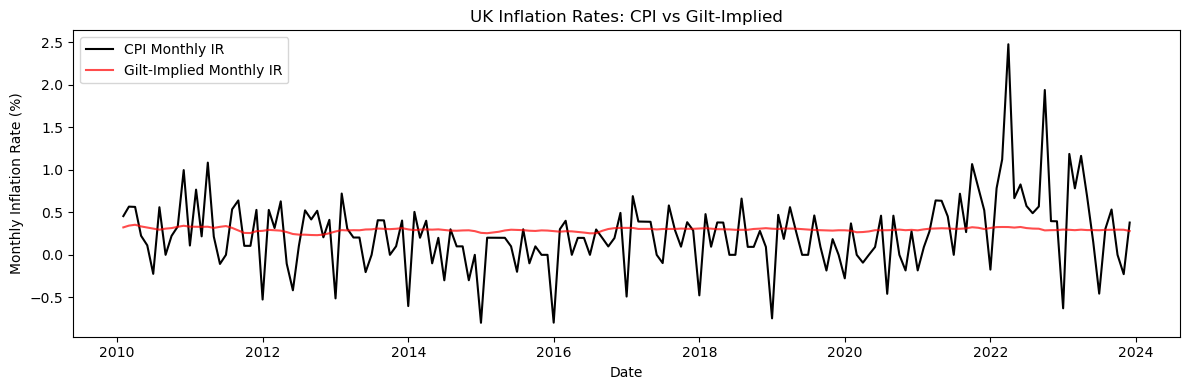

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(merged_train['date'], merged_train['ir_pct'], 'k-', linewidth=1.5, label='CPI Monthly IR')
ax.plot(merged_train['date'], merged_train['ir_implied'], 'r-', linewidth=1.5, alpha=0.7,
        label='Gilt-Implied Monthly IR')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Inflation Rate (%)')
ax.set_title('UK Inflation Rates: CPI vs Gilt-Implied')
ax.legend()
plt.tight_layout()
plt.show()

Before adding the gilt-implied rate as a regressor, we check the cross-correlation to identify any lead-lag structure. This tells us which lag of the exogenous variable to include in the model.

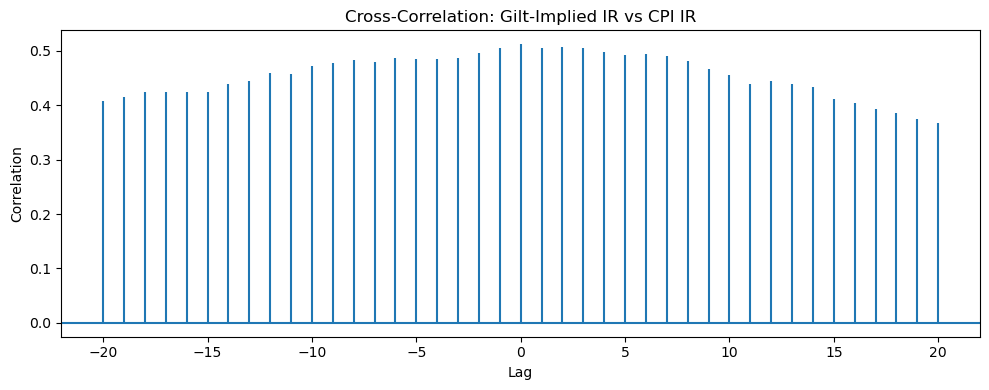

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.xcorr(
    merged_train['ir_implied'].dropna().values,
    merged_train['ir_pct'].dropna().values[-len(merged_train['ir_implied'].dropna()):],
    maxlags=20,
    usevlines=True, linewidth=1.5
)
ax.set_title('Cross-Correlation: Gilt-Implied IR vs CPI IR')
ax.set_xlabel('Lag')
ax.set_ylabel('Correlation')
plt.tight_layout()
plt.show()

The CCF suggests the strongest association is contemporaneous (lag 0). We therefore include the gilt-implied inflation at the same time instant as an exogenous regressor in an AR(2) model.

In [18]:
# Prepare the endogenous and exogenous variables
endog_train = merged_train['ir_pct'].values
exog_train = merged_train[['ir_implied']].values

endog_test = merged_test['ir_pct'].values
exog_test = merged_test[['ir_implied']].values

# Fit AR(2) with exogenous regressor
arx_model = AutoReg(endog_train, lags=2, exog=exog_train, trend='c').fit()
print('ARX(2) Model with gilt-implied inflation as exogenous regressor:')
print(arx_model.params)
print(f'\nAIC: {arx_model.aic:.2f}')

ARX(2) Model with gilt-implied inflation as exogenous regressor:
[-1.03390271  0.08057029  0.1328447   4.14330653]

AIC: 185.66


In [19]:
# Walk-forward predictions on test set
arx_coeffs = arx_model.params
history_arx = list(endog_train[-2:])
arx_test_preds = []

for j in range(len(endog_test)):
    # ARX prediction: const + ar1*y_{t-1} + ar2*y_{t-2} + beta*exog_t
    yhat = arx_coeffs[0]  # const
    yhat += arx_coeffs[1] * history_arx[-1]  # ar.L1
    yhat += arx_coeffs[2] * history_arx[-2]  # ar.L2
    yhat += arx_coeffs[3] * exog_test[j, 0]   # exogenous
    arx_test_preds.append(yhat)
    history_arx.append(endog_test[j])  # use actual for next step

arx_test_preds = np.array(arx_test_preds)

# In-sample fitted values
arx_train_fitted = arx_model.predict(start=2, end=len(endog_train)-1, exog_oos=exog_train[2:])

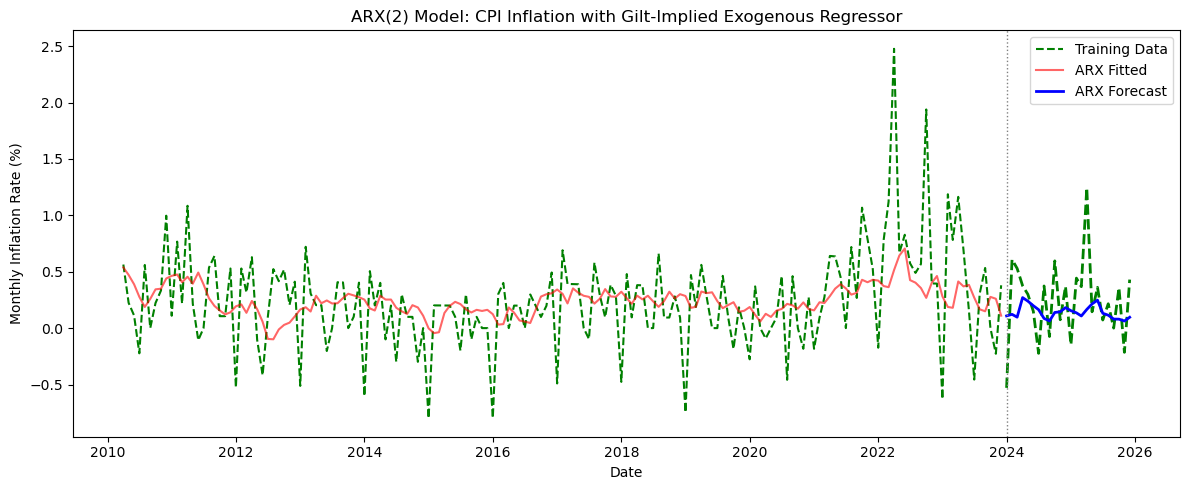

ARX(2) Test RMSE: 0.3578
ARX(2) Test MAPE: 84.66%


In [20]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(merged_train['date'].values[2:], endog_train[2:], 'g--', linewidth=1.5, label='Training Data')
ax.plot(merged_train['date'].values[2:], arx_train_fitted, 'r-', linewidth=1.5, alpha=0.6, label='ARX Fitted')
ax.plot(merged_test['date'], endog_test, 'g--', linewidth=2)
ax.plot(merged_test['date'], arx_test_preds, 'b-', linewidth=2, label='ARX Forecast')
ax.axvline(x=merged_test['date'].values[0], color='grey', linestyle=':', linewidth=1)
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Inflation Rate (%)')
ax.set_title('ARX(2) Model: CPI Inflation with Gilt-Implied Exogenous Regressor')
ax.legend()
plt.tight_layout()
plt.show()

arx_rmse = np.sqrt(mean_squared_error(endog_test, arx_test_preds))
arx_mape = mean_absolute_percentage_error(endog_test[endog_test != 0],
                                           arx_test_preds[endog_test != 0]) * 100
print(f'ARX(2) Test RMSE: {arx_rmse:.4f}')
print(f'ARX(2) Test MAPE: {arx_mape:.2f}%')

Finally, we try incorporating a Moving Average term to see if it improves things. Adding MA(1) gives us an ARMAX(2,1) model. We re-estimate the model at each test step for a fair comparison.

In [21]:
# Fit ARMA(2,1) with exogenous regressor using ARIMA interface
armax_model = ARIMA(endog_train, order=(2, 0, 1), exog=exog_train).fit()
print('ARMAX(2,1) Model Summary:')
print(armax_model.summary().tables[1])

ARMAX(2,1) Model Summary:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2446      0.521     -2.387      0.017      -2.267      -0.223
x1             5.0356      1.759      2.863      0.004       1.588       8.483
ar.L1         -0.7804      0.088     -8.835      0.000      -0.954      -0.607
ar.L2          0.2196      0.088      2.508      0.012       0.048       0.391
ma.L1          0.9979      0.127      7.835      0.000       0.748       1.248
sigma2         0.1473      0.023      6.383      0.000       0.102       0.193


In [22]:
# Generate test forecasts using the ARMAX model
armax_forecast = armax_model.forecast(steps=len(endog_test), exog=exog_test)

# For a fairer comparison, also do step-by-step with appended observations
armax_step_preds = []
armax_refit = ARIMA(endog_train, order=(2, 0, 1), exog=exog_train).fit()
history_armax = list(endog_train)
exog_hist = list(exog_train)

for j in range(len(endog_test)):
    # One-step-ahead forecast
    fc = armax_refit.forecast(steps=1, exog=exog_test[j:j+1])
    armax_step_preds.append(fc[0])
    # Append actual observation and refit
    history_armax.append(endog_test[j])
    exog_hist.append(exog_test[j])
    armax_refit = ARIMA(np.array(history_armax), order=(2, 0, 1),
                        exog=np.array(exog_hist)).fit()

armax_step_preds = np.array(armax_step_preds)

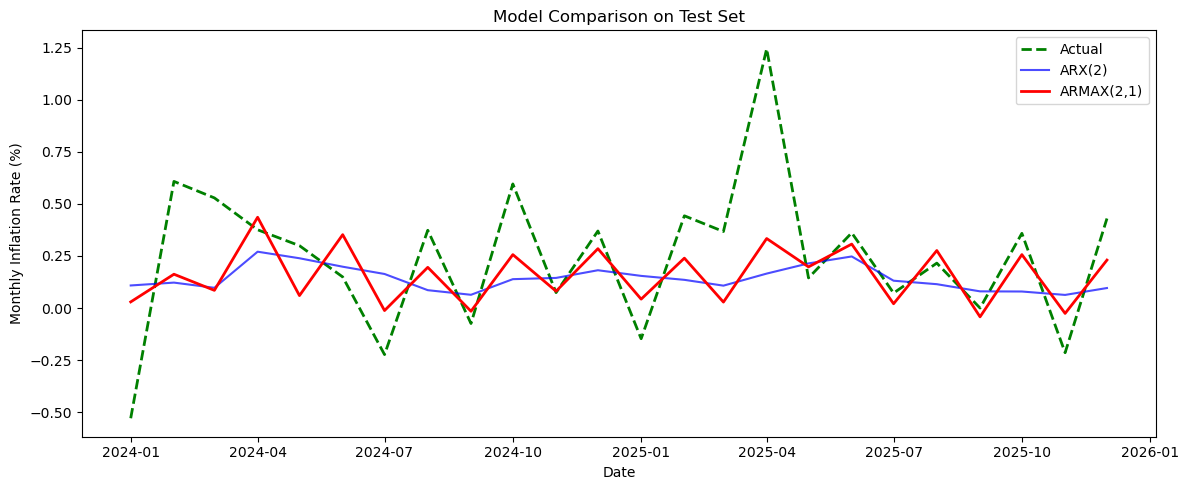


Model Comparison (Test Set):
Model                      RMSE   MAPE (%)
ARX(2)                   0.3578      84.66
ARMAX(2,1)               0.2984      63.47


In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(merged_test['date'], endog_test, 'g--', linewidth=2, label='Actual')
ax.plot(merged_test['date'], arx_test_preds, 'b-', linewidth=1.5, alpha=0.7, label='ARX(2)')
ax.plot(merged_test['date'], armax_step_preds, 'r-', linewidth=2, label='ARMAX(2,1)')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Inflation Rate (%)')
ax.set_title('Model Comparison on Test Set')
ax.legend()
plt.tight_layout()
plt.show()

armax_rmse = np.sqrt(mean_squared_error(endog_test, armax_step_preds))
armax_mape = mean_absolute_percentage_error(
    endog_test[endog_test != 0],
    armax_step_preds[endog_test != 0]
) * 100

print(f'\nModel Comparison (Test Set):')
print(f'{"Model":<20} {"RMSE":>10} {"MAPE (%)":>10}')
print(f'{"ARX(2)":<20} {arx_rmse:>10.4f} {arx_mape:>10.2f}')
print(f'{"ARMAX(2,1)":<20} {armax_rmse:>10.4f} {armax_mape:>10.2f}')

We see that the ARMAX model may trade off $\text{RMSE}$ against $\text{MAPE}$, a lower $\text{MAPE}$ means the average percentage error has improved, even if the absolute error measure has shifted. This kind of trade-off is worth examining in context: for headline CPI reporting, consistent small errors may matter more than occasional large ones.

### Data Sources
- **CPI**: ONS Series D7BT -- CPI All Items Index (2015=100), [ons.gov.uk](https://www.ons.gov.uk/economy/inflationandpriceindices/timeseries/d7bt/mm23)
- **Implied Inflation**: Bank of England Series IUMAMIIF -- 10 Year Inflation Implied Forward (Monthly Average), [bankofengland.co.uk](https://www.bankofengland.co.uk/statistics/yield-curves)